# Joint discourse x semantic analysis (RQ2)

Two finished layers, combined; neither is modified, re-run or reinterpreted here.

| layer | input | status |
|---|---|---|
| discourse | `discopy_explicit_candidates.csv`, `is_connective == True` | frozen 2026-08-27 |
| semantic | `full_frozen/annotations.jsonl` | frozen |

**The question.** *Which explicit discourse relations tend to occur in
sentences containing each semantic category?*

### What this establishes, and what it does not

The parser identifies explicit connectives and their PDTB sense. It does
**not** recover discourse arguments, and this analysis never asks it to. So
what follows is a **sentence-level association between the form of a sentence
and the kind of information it carries**.

Legitimate readings:

* "Sentences containing Payoff information carry Contingency relations more
  often in 31B than in E4B."
* "Contingency is overrepresented in sentences containing Mechanical
  information."

Readings this analysis does **not** support:

* "Contingency is used to express Mechanical reasoning."
* "The connective links the Mechanical evidence to the conclusion."
* "Mechanical evidence is an argument of the Contingency relation."

### Design rules, inherited from both frozen strands

| rule | why |
|---|---|
| the unit is the **canonical sentence** (semantic-layer segmentation) | the two pipelines share `src/utils/sentences.split_sentences`, so sentence ids are joinable |
| **presence, not counts** | a sentence with two Contingency relations counts once for any (category, Contingency) pair |
| each run computed independently, then mean and SD over the three stochastic runs | a run is a realisation, not a sample |
| **greedy always separate**, SD undefined | one deterministic run per game |
| the bootstrap resamples **games**, with all runs and sentences attached, same ids across models | stochastic runs of a game are not independent games |
| 10,000 replicates, seed `20260826`, percentile CIs, **no p-values** | descriptive uncertainty, not a decision rule |
| **lift is not bootstrapped** | it stays descriptive, matching the semantic strand |

Computation lives in `src/justification_analysis/joint/`.

## 1. Setup and paths

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display


def find_repo_root(start=None, repo_name="masters_thesis_sdg"):
    current = (start or Path.cwd()).resolve()
    while current.name != repo_name:
        if current.parent == current:
            raise FileNotFoundError(f"repo root {repo_name!r} not found")
        current = current.parent
    return current


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.justification_analysis.joint import joint_final as jf
from src.justification_analysis.joint import joint_figures as jfig

FINAL_TABLES = REPO_ROOT / jf.FINAL_TABLES_SUBPATH
FINAL_FIGURES = REPO_ROOT / jf.FINAL_FIGURES_SUBPATH
FINAL_TABLES.mkdir(parents=True, exist_ok=True)
FINAL_FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)

print("discourse :", jf.DISCOURSE_SUBPATH)
print("semantic  :", jf.sem.ANNOTATIONS_SUBPATH)
print("tables    :", FINAL_TABLES.relative_to(REPO_ROOT))
print("figures   :", FINAL_FIGURES.relative_to(REPO_ROOT))
print()
print("semantic categories :", ", ".join(jf.CATEGORY_ORDER))
print("discourse classes   :", ", ".join(jf.TOP_LEVEL_ORDER))
print("thin-support flag   : N(c) <", jf.THIN_SUPPORT, "sentences per run")
print(f"bootstrap           : {jf.BOOTSTRAP_REPLICATES:,} replicates, "
      f"seed {jf.BOOTSTRAP_SEED}")

discourse : analysis\cross_model\base\voting\prompt_v4\justification_analysis\discourse_parser\discopy_explicit_candidates.csv
semantic  : results\justification_annotation\full_frozen\annotations.jsonl
tables    : analysis\cross_model\base\voting\prompt_v4\justification_analysis\joint_discourse_semantic\thesis_tables\final_joint
figures   : analysis\cross_model\base\voting\prompt_v4\justification_analysis\joint_discourse_semantic\figures\final_joint

semantic categories : Mechanical, Testimony, SocialJudgment, Behavioral, ClaimComparison, Payoff, Uncertainty
discourse classes   : Comparison, Contingency, Expansion, Temporal
thin-support flag   : N(c) < 30 sentences per run
bootstrap           : 10,000 replicates, seed 20260826


## 2. Load the two frozen layers

Only `is_connective == True` rows are relations. The rejected NoSense
candidates stay in the source table so the accept/reject behaviour remains
inspectable, but they are not relations and never enter this analysis.

In [2]:
layers = jf.load_layers(REPO_ROOT)

print("discourse candidates :", len(layers["candidates"]))
print("accepted relations   :", len(layers["relations"]))
print("rejected (NoSense)   :",
      len(layers["candidates"]) - len(layers["relations"]))
print()
for name, frame in layers["semantic"].items():
    print(f"semantic {name:14s} {frame.shape}")

discourse candidates : 14209
accepted relations   : 5504
rejected (NoSense)   : 8705

semantic justifications (2292, 22)
semantic sentences      (8044, 5)
semantic labels         (11526, 6)
semantic repairs        (1, 7)


## 3. Alignment - exact, and verified rather than assumed

Both layers already carry `(model, game_id, run_label, sentence_id)`, because
the parser was run over the same fixed segmentation the annotator saw. So the
join is on those identifiers - **no character-offset mapping and no fuzzy text
matching is needed**.

The join is nonetheless **verified**: the sentence text the parser scored is
compared byte for byte against the canonical sentence text. A relation that
fails either the key join or the text check is returned in `unaligned` and
reported, never silently matched.

In [3]:
alignment = jf.align_relations(layers)

aligned = alignment["aligned"]
unaligned = alignment["unaligned"]

print(f"accepted relations         : {len(layers['relations'])}")
print(f"aligned to a sentence      : {len(aligned)}")
print(f"UNALIGNED                  : {len(unaligned)}")
print()
print("every aligned relation matched its canonical sentence text exactly:",
      bool((aligned["sentence_text"].astype(str)
            == aligned["text"].astype(str)).all()))

if len(unaligned):
    display(unaligned)
else:
    print("nothing to report - the alignment is complete and unambiguous")

accepted relations         : 5504
aligned to a sentence      : 5504
UNALIGNED                  : 0

every aligned relation matched its canonical sentence text exactly: True
nothing to report - the alignment is complete and unambiguous


### 3.1 The 29 discontinuous connectives

`if then`, `either or` and `neither nor` are stored with their surface joined
and two character spans. Their surface is therefore not a literal substring of
the sentence - which is a property of how the surface is recorded, **not** an
alignment problem: both spans lie inside the same canonical sentence, and the
sentence assignment is exact. Recorded here so the count is on the record.

In [4]:
surface_inside = [
    surface in text for surface, text
    in zip(aligned["connective_surface"].astype(str),
           aligned["text"].astype(str))
]
odd = aligned.loc[~np.array(surface_inside)]

print(f"connective surface not a literal substring: {len(odd)} of {len(aligned)}")
print("all of them discontinuous:", bool(odd["is_discontinuous"].all()))
print("all carry two character spans:", bool((odd["n_char_spans"] == 2).all()))
print()
display(odd["connective_surface"].value_counts().rename("n").to_frame())

connective surface not a literal substring: 29 of 5504
all of them discontinuous: True
all carry two character spans: True



,n
connective_surface,
If then,24
either or,3
if then,2


## 4. The joint sentence dataset

One row per canonical sentence, both layers as presence flags. Multi-label
structure is preserved on both sides. Sentences with no relation and/or no
semantic label are **kept** - dropping them would silently change every
denominator below.

In [5]:
joint = jf.build_joint_sentences(layers, alignment)

print("joint sentences:", joint.shape)
print()
print("sentences carrying at least one explicit relation:",
      int(joint["has_any_relation"].sum()),
      f"({100 * joint['has_any_relation'].mean():.1f}%)")
print("sentences carrying at least one substantive category:",
      int((joint["n_semantic_categories"] > 0).sum()),
      f"({100 * (joint['n_semantic_categories'] > 0).mean():.1f}%)")
print()
display(joint.head(3)[
    ["model", "game_id", "run_label", "sentence_id", "n_semantic_categories",
     "n_relations", "has_any_relation"]])

joint sentences: (8044, 32)

sentences carrying at least one explicit relation: 4097 (50.9%)


sentences carrying at least one substantive category: 7618 (94.7%)



,model,game_id,run_label,sentence_id,n_semantic_categories,n_relations,has_any_relation
0,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,1,1,0,False
1,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,2,2,1,True
2,Gemma 4 2B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,run_1,3,1,0,False


## 5. Validation report

Both source analyses are frozen, so anything that disagrees with them is a bug
in **this** module, not a new finding. The notebook asserts on the result.

In [6]:
validation = jf.validation_report(layers, alignment, joint)
display(validation)

failures = validation.loc[validation["status"] == "FAIL"]
assert len(failures) == 0, f"validation failed:\n{failures}"
print(f"all {len(validation)} validation checks passed")

,check,observed,expected,status
0,justifications represented,2292,2292,OK
1,canonical sentences,8044,8044,OK
2,games,191,191,OK
3,discourse candidates in source table,14209,14209,OK
4,accepted discourse relations,5504,5504,OK
5,accepted relations aligned to a canonical sent...,5504,5504,OK
6,relations that could NOT be aligned,0,0,OK
7,every relation assigned to exactly one sentence,0,0,OK
8,no duplicate canonical sentences,0,0,OK
9,no duplicate sentence keys,0,0,OK


all 23 validation checks passed


## 6. How often is any explicit relation present at all?

Table D. This has to be known before any per-class `P(r|c)` is read: if one
semantic category simply occurs in more explicitly-connected sentences than
another, every one of its per-class values inherits that.

In [7]:
run_level = jf.conditional_prevalence(joint, "top_level")
any_relation = jf.any_relation_given_category(run_level)

stochastic_any = any_relation.loc[
    any_relation["decoding_group"].astype(str).eq("Stochastic")]

print("P(at least one explicit relation | semantic category), %")
display((100 * stochastic_any.pivot_table(
    index="semantic_category", columns="model",
    values="mean_conditional_prevalence", observed=True)).round(1))

print("mean N(c) per run - the denominator behind every cell below")
display(stochastic_any.pivot_table(
    index="semantic_category", columns="model",
    values="mean_n_semantic_sentences", observed=True).round(0))

P(at least one explicit relation | semantic category), %


model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B
semantic_category,,,
Mechanical,60.5,67.1,73.6
Testimony,63.1,64.9,53.4
SocialJudgment,64.9,48.2,58.7
Behavioral,58.0,49.9,55.7
ClaimComparison,69.1,63.2,63.6
Payoff,61.6,37.3,76.9
Uncertainty,52.3,44.8,59.0


mean N(c) per run - the denominator behind every cell below


model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B
semantic_category,,,
Mechanical,6.0,15.0,123.0
Testimony,142.0,235.0,420.0
SocialJudgment,186.0,230.0,71.0
Behavioral,39.0,218.0,173.0
ClaimComparison,17.0,54.0,162.0
Payoff,199.0,159.0,57.0
Uncertainty,196.0,112.0,22.0


### 6.1 Thin denominators

Several model-category combinations rest on very few sentences. They are
**flagged, never dropped**: deleting them would hide which combinations the
corpus cannot speak to. Nothing hatched in the figures, or flagged here, should
be interpreted.

In [8]:
thin = stochastic_any.loc[stochastic_any["support_is_thin"]]
print(f"model x category combinations below {jf.THIN_SUPPORT} sentences/run:")
display(thin[["model", "semantic_category", "mean_n_semantic_sentences",
              "total_n_semantic_sentences"]].round(1).reset_index(drop=True))

model x category combinations below 30 sentences/run:


,model,semantic_category,mean_n_semantic_sentences,total_n_semantic_sentences
0,Gemma 4 2B,Mechanical,6.0,18
1,Gemma 4 2B,ClaimComparison,17.0,51
2,Gemma 4 4B,Mechanical,15.3,46
3,Gemma 4 31B,Uncertainty,22.0,66


## 7. Primary metric: conditional prevalence P(r | c)

For semantic category *c* and discourse class *r*:

$$P(r \mid c) = \frac{N(c, r)}{N(c)}$$

where `N(c)` counts canonical sentences containing *c*, and `N(c,r)` counts
those that **also** contain at least one explicit relation of class *r*.

Reads: *among sentences containing this semantic category, the proportion that
also contain an explicit relation of this class.* Sentence-level presence, not
relation counts.

In [9]:
prevalence = jf.conditional_prevalence_summary(run_level)
substantive = prevalence.loc[
    prevalence["discourse_relation"].astype(str).ne(jf.ANY_RELATION)]

for model in jf.MODEL_ORDER:
    print(f"{model} - P(r|c) %, stochastic mean of 3 runs")
    display((100 * jf.prevalence_matrix(
        substantive, model, "Stochastic")).round(1))

Gemma 4 2B - P(r|c) %, stochastic mean of 3 runs


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,16.2,27.3,39.8,5.6
Testimony,28.9,8.8,27.8,13.2
SocialJudgment,29.9,12.7,25.1,9.5
Behavioral,27.5,15.5,20.2,9.4
ClaimComparison,33.1,5.1,33.4,34.0
Payoff,7.5,50.5,17.1,1.0
Uncertainty,28.6,20.4,17.9,0.9


Gemma 4 4B - P(r|c) %, stochastic mean of 3 runs


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,36.4,16.0,9.1,12.6
Testimony,32.7,11.5,17.2,16.8
SocialJudgment,30.0,3.8,16.9,7.7
Behavioral,33.0,4.7,14.1,9.8
ClaimComparison,24.6,4.8,14.2,36.7
Payoff,13.8,18.8,14.1,1.0
Uncertainty,34.7,7.8,7.2,1.4


Gemma 4 31B - P(r|c) %, stochastic mean of 3 runs


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,11.7,50.2,24.3,13.9
Testimony,16.3,13.2,22.6,17.1
SocialJudgment,24.5,9.5,28.7,12.0
Behavioral,23.2,16.2,20.8,14.3
ClaimComparison,19.0,13.9,20.1,30.7
Payoff,19.0,54.0,33.2,5.4
Uncertainty,40.9,14.2,26.8,6.0


In [10]:
# Run-to-run spread, so the reader can see how stable these are.
print("SD across the three stochastic runs, percentage points")
for model in jf.MODEL_ORDER:
    display((100 * jf.prevalence_matrix(
        substantive, model, "Stochastic",
        "sd_conditional_prevalence")).round(1))

SD across the three stochastic runs, percentage points


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,14.7,6.8,21.8,9.6
Testimony,0.9,4.5,5.8,2.4
SocialJudgment,3.3,2.5,1.6,2.5
Behavioral,6.2,1.4,7.3,2.5
ClaimComparison,2.3,4.8,8.5,14.7
Payoff,1.0,3.1,2.0,0.5
Uncertainty,1.3,0.6,2.6,0.8


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,7.0,6.4,4.7,4.3
Testimony,0.7,0.7,1.3,2.5
SocialJudgment,2.3,1.2,4.5,1.4
Behavioral,0.7,0.8,2.2,2.1
ClaimComparison,4.5,3.6,6.4,4.0
Payoff,1.6,3.2,3.3,1.0
Uncertainty,5.2,2.7,0.8,0.8


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,1.7,2.1,5.6,2.1
Testimony,1.6,1.1,0.8,2.4
SocialJudgment,2.6,2.2,3.0,2.8
Behavioral,0.3,2.2,2.4,2.8
ClaimComparison,1.9,2.5,1.5,2.9
Payoff,2.9,6.0,0.3,3.5
Uncertainty,0.9,7.4,8.1,1.9


## 8. Secondary metric: sentence-level lift

$$L(c,r) = \frac{P(c,r)}{P(c)\,P(r)}$$

over canonical sentences. Above 1 the pair shares a sentence more often than
sentence-level independence implies; below 1, less often.

**Diagnostic only.** Raw support travels in the same table and is never
dropped, because on a thin denominator the ratio moves on a couple of
sentences.

In [11]:
lift_run_level = jf.joint_prevalence_and_lift(joint, "top_level")
lift = jf.lift_summary(lift_run_level)
lift_substantive = lift.loc[
    lift["discourse_relation"].astype(str).ne(jf.ANY_RELATION)]

for model in jf.MODEL_ORDER:
    print(f"{model} - lift, stochastic mean")
    display(jf.prevalence_matrix(
        lift_substantive, model, "Stochastic", "mean_lift").round(2))

Gemma 4 2B - lift, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,0.83,1.29,2.22,1.27
Testimony,1.50,0.41,1.58,2.60
SocialJudgment,1.55,0.61,1.44,1.81
Behavioral,1.43,0.75,1.17,1.80
ClaimComparison,1.72,0.25,1.89,6.56
Payoff,0.39,2.42,0.99,0.19
Uncertainty,1.48,0.98,1.02,0.15


Gemma 4 4B - lift, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,1.46,1.58,0.67,1.68
Testimony,1.31,1.16,1.30,2.18
SocialJudgment,1.20,0.37,1.26,0.99
Behavioral,1.32,0.47,1.07,1.27
ClaimComparison,0.98,0.52,1.10,4.82
Payoff,0.55,1.88,1.05,0.15
Uncertainty,1.38,0.78,0.55,0.18


Gemma 4 31B - lift, stochastic mean


discourse_relation,Comparison,Contingency,Expansion,Temporal
semantic_category,,,,
Mechanical,0.80,2.42,1.19,1.05
Testimony,1.12,0.63,1.11,1.29
SocialJudgment,1.69,0.45,1.41,0.93
Behavioral,1.60,0.78,1.03,1.08
ClaimComparison,1.30,0.66,0.99,2.34
Payoff,1.31,2.58,1.63,0.39
Uncertainty,2.82,0.69,1.33,0.47


In [12]:
# Ranked, with support in view and thin denominators excluded from the ranking
# but not from the table.
stochastic_lift = lift_substantive.loc[
    lift_substantive["decoding_group"].astype(str).eq("Stochastic")].copy()
stochastic_lift["distance_from_1"] = (stochastic_lift["mean_lift"] - 1).abs()

solid = stochastic_lift.loc[~stochastic_lift["support_is_thin"]]
print("strongest associations on solid support, ranked by |lift - 1|")
display(solid.nlargest(15, "distance_from_1")[
    ["model", "semantic_category", "discourse_relation", "mean_lift",
     "sd_lift", "total_support", "mean_joint_prevalence"]
].round(3).reset_index(drop=True))

print("the same ranking among THIN cells - reported so it is visible, "
      "not to be interpreted")
display(stochastic_lift.loc[stochastic_lift["support_is_thin"]]
        .nlargest(5, "distance_from_1")[
            ["model", "semantic_category", "discourse_relation", "mean_lift",
             "total_support"]].round(3).reset_index(drop=True))

strongest associations on solid support, ranked by |lift - 1|


,model,semantic_category,discourse_relation,mean_lift,sd_lift,total_support,mean_joint_prevalence
0,Gemma 4 4B,ClaimComparison,Temporal,4.818,0.857,60,0.027
1,Gemma 4 2B,Testimony,Temporal,2.596,0.674,56,0.031
2,Gemma 4 31B,Payoff,Contingency,2.584,0.134,94,0.047
3,Gemma 4 2B,Payoff,Contingency,2.422,0.122,301,0.167
4,Gemma 4 31B,Mechanical,Contingency,2.420,0.260,185,0.093
5,Gemma 4 31B,ClaimComparison,Temporal,2.344,0.314,149,0.075
6,Gemma 4 4B,Testimony,Temporal,2.179,0.087,119,0.053
7,Gemma 4 4B,Payoff,Contingency,1.876,0.096,90,0.040
8,Gemma 4 4B,Payoff,Temporal,0.149,0.154,5,0.002
9,Gemma 4 2B,Uncertainty,Temporal,0.153,0.133,5,0.003


the same ranking among THIN cells - reported so it is visible, not to be interpreted


,model,semantic_category,discourse_relation,mean_lift,total_support
0,Gemma 4 2B,ClaimComparison,Temporal,6.555,17
1,Gemma 4 31B,Uncertainty,Comparison,2.825,27
2,Gemma 4 2B,Mechanical,Expansion,2.219,7
3,Gemma 4 2B,ClaimComparison,Expansion,1.890,17
4,Gemma 4 2B,ClaimComparison,Contingency,0.252,3


## 9. Cross-model comparison: paired game-level bootstrap of P(r|c)

One replicate: resample the 191 game ids with replacement; use the **same** ids
for every model; keep every run and every sentence of a sampled game; recompute
`P(r|c)` per run; average the three run values into one model value; difference
the models.

A replicate whose resampled games contain no sentence with category *c* has no
defined `P(r|c)`; those replicates are dropped and counted in
`n_valid_replicates` rather than treated as zero.

In [13]:
bootstrap = jf.conditional_prevalence_bootstrap(joint, "top_level")
stochastic_bootstrap = bootstrap.loc[
    bootstrap["decoding_group"].astype(str).eq("Stochastic")
    & bootstrap["discourse_relation"].astype(str).ne(jf.ANY_RELATION)]

total = len(stochastic_bootstrap)
excluding = int(stochastic_bootstrap["ci_excludes_zero"].sum())
solid_excluding = int((stochastic_bootstrap["ci_excludes_zero"]
                       & ~stochastic_bootstrap["support_is_thin"]).sum())
print(f"{total} stochastic comparisons "
      f"(7 categories x 4 classes x 3 model pairs)")
print(f"intervals excluding zero: {excluding}")
print(f"  of which on solid support: {solid_excluding}")

84 stochastic comparisons (7 categories x 4 classes x 3 model pairs)
intervals excluding zero: 34
  of which on solid support: 25


In [14]:
ranked = stochastic_bootstrap.loc[
    stochastic_bootstrap["ci_excludes_zero"]
    & ~stochastic_bootstrap["support_is_thin"]].copy()
ranked["magnitude"] = ranked["difference"].abs()

print("largest well-supported model differences in P(r|c)")
display(ranked.nlargest(20, "magnitude")[
    ["semantic_category", "discourse_relation", "model_a", "model_b",
     "prevalence_a", "prevalence_b", "difference", "ci_low", "ci_high"]
].round(3).reset_index(drop=True))

largest well-supported model differences in P(r|c)


,semantic_category,discourse_relation,model_a,model_b,prevalence_a,prevalence_b,difference,ci_low,ci_high
0,Payoff,Contingency,Gemma 4 4B,Gemma 4 31B,0.188,0.540,-0.352,-0.438,-0.265
1,Payoff,Contingency,Gemma 4 2B,Gemma 4 4B,0.505,0.188,0.317,0.256,0.378
2,Payoff,Expansion,Gemma 4 4B,Gemma 4 31B,0.141,0.332,-0.191,-0.281,-0.101
3,Testimony,Comparison,Gemma 4 4B,Gemma 4 31B,0.327,0.163,0.165,0.121,0.207
4,Payoff,Expansion,Gemma 4 2B,Gemma 4 31B,0.171,0.332,-0.161,-0.248,-0.073
5,Testimony,Comparison,Gemma 4 2B,Gemma 4 31B,0.289,0.163,0.126,0.076,0.176
6,Uncertainty,Contingency,Gemma 4 2B,Gemma 4 4B,0.204,0.078,0.126,0.091,0.160
7,SocialJudgment,Expansion,Gemma 4 4B,Gemma 4 31B,0.169,0.287,-0.118,-0.190,-0.048
8,Behavioral,Contingency,Gemma 4 4B,Gemma 4 31B,0.047,0.162,-0.115,-0.152,-0.078
9,Payoff,Comparison,Gemma 4 2B,Gemma 4 31B,0.075,0.190,-0.114,-0.186,-0.047


## 10. Fine-grained PDTB senses - supplementary

Its purpose is to explain the top-level pairings, not to generate new results.
Only the pairings that stood out above are examined.

In [15]:
fine_run_level = jf.conditional_prevalence(joint, "sense")
fine = jf.conditional_prevalence_summary(fine_run_level)
fine_stochastic = fine.loc[fine["decoding_group"].astype(str).eq("Stochastic")]

for category, parent in (("Payoff", "Contingency"),
                         ("Mechanical", "Contingency"),
                         ("ClaimComparison", "Temporal"),
                         ("Uncertainty", "Comparison")):
    subset = fine_stochastic.loc[
        fine_stochastic["semantic_category"].astype(str).eq(category)
        & fine_stochastic["discourse_relation"].astype(str)
        .str.startswith(parent)]
    print(f"{category} x {parent}.* - P(sense | category), %")
    display((100 * subset.pivot_table(
        index="discourse_relation", columns="model",
        values="mean_conditional_prevalence", observed=True)).round(1))

Payoff x Contingency.* - P(sense | category), %

model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B
discourse_relation,,,
Contingency.Cause,47.7,15.5,32.3
Contingency.Condition,9.9,6.5,24.5


Mechanical x Contingency.* - P(sense | category), %


model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B
discourse_relation,,,
Contingency.Cause,21.7,13.4,21.7
Contingency.Condition,11.1,2.6,31.5


ClaimComparison x Temporal.* - P(sense | category), %


model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B
discourse_relation,,,
Temporal.Asynchronous,25.7,35.5,27.3
Temporal.Synchrony,8.3,1.9,4.3


Uncertainty x Comparison.* - P(sense | category), %


model,Gemma 4 2B,Gemma 4 4B,Gemma 4 31B
discourse_relation,,,
Comparison.Contrast,28.1,34.7,40.9
Comparison.Concession,0.5,0.0,0.0


## 11. Greedy robustness

Greedy is one deterministic run per game, reported separately throughout. The
only question here is whether it tells the same story.

In [16]:
comparison = (
    substantive.loc[substantive["decoding_group"].astype(str).eq("Stochastic")]
    .set_index(["model", "semantic_category", "discourse_relation"])
    ["mean_conditional_prevalence"].rename("stochastic").to_frame()
    .join(substantive.loc[
        substantive["decoding_group"].astype(str).eq("Greedy")]
        .set_index(["model", "semantic_category", "discourse_relation"])
        ["mean_conditional_prevalence"].rename("greedy"))
    .join(substantive.loc[
        substantive["decoding_group"].astype(str).eq("Stochastic")]
        .set_index(["model", "semantic_category", "discourse_relation"])
        ["support_is_thin"])
).dropna(subset=["stochastic", "greedy"])
comparison["gap_pp"] = 100 * (comparison["greedy"] - comparison["stochastic"])

solid_cells = comparison.loc[~comparison["support_is_thin"]]
print(f"all {len(comparison)} cells      : r = "
      f"{comparison['stochastic'].corr(comparison['greedy']):.3f}, "
      f"mean |gap| = {comparison['gap_pp'].abs().mean():.1f} pp, "
      f"max = {comparison['gap_pp'].abs().max():.1f} pp")
print(f"{len(solid_cells)} solid cells   : r = "
      f"{solid_cells['stochastic'].corr(solid_cells['greedy']):.3f}, "
      f"mean |gap| = {solid_cells['gap_pp'].abs().mean():.1f} pp, "
      f"max = {solid_cells['gap_pp'].abs().max():.1f} pp")

print("largest greedy-stochastic gaps")
display(comparison.reindex(
    comparison["gap_pp"].abs().sort_values(ascending=False).index
).head(8).round(3))

all 84 cells      : r = 0.856, mean |gap| = 4.4 pp, max = 26.9 pp
68 solid cells   : r = 0.961, mean |gap| = 2.7 pp, max = 10.3 pp
largest greedy-stochastic gaps


stochastic  greedy  support_is_thin  gap_pp
model       semantic_category discourse_relation                                             
Gemma 4 4B  Mechanical        Contingency              0.160   0.429             True  26.894
                              Comparison               0.364   0.143             True -22.094
Gemma 4 2B  Mechanical        Expansion                0.398   0.200             True -19.841
Gemma 4 31B Uncertainty       Contingency              0.142   0.312             True  17.067
Gemma 4 2B  ClaimComparison   Comparison               0.331   0.500             True  16.868
                              Expansion                0.334   0.500             True  16.638
            Mechanical        Comparison               0.162   0.000             True -16.190
                              Temporal                 0.056   0.200             True  14.444

## 12. Figures, export and final checks

In [17]:
tables = jf.build_final_tables(layers, alignment, joint)
for path in jf.write_final_tables(tables, FINAL_TABLES):
    print("wrote", path.name)

wrote J0_validation_report.csv
wrote J0b_unaligned_relations.csv
wrote J1_conditional_prevalence_run_level.csv
wrote J2_conditional_prevalence_summary.csv
wrote J2_conditional_prevalence_summary.tex
wrote J3_joint_prevalence_lift_run_level.csv
wrote J3b_joint_prevalence_lift_summary.csv
wrote J4_any_relation_given_category.csv
wrote J4_any_relation_given_category.tex
wrote J5_bootstrap_model_differences.csv
wrote J5_bootstrap_model_differences.tex
wrote J6_finegrained_conditional_prevalence_run_level.csv
wrote J6b_finegrained_conditional_prevalence_summary.csv
wrote J7_finegrained_joint_prevalence_lift_summary.csv


In [18]:
figure_paths = jfig.build_final_figures(tables, FINAL_FIGURES)
for path in figure_paths:
    print("wrote", path.name)

wrote F1_joint_conditional_prevalence.png
wrote F2_joint_lift.png
wrote F1b_joint_conditional_prevalence_greedy.png
wrote F2b_joint_lift_greedy.png


### 12.1 Figures, rendered for inspection

F1_joint_conditional_prevalence.png


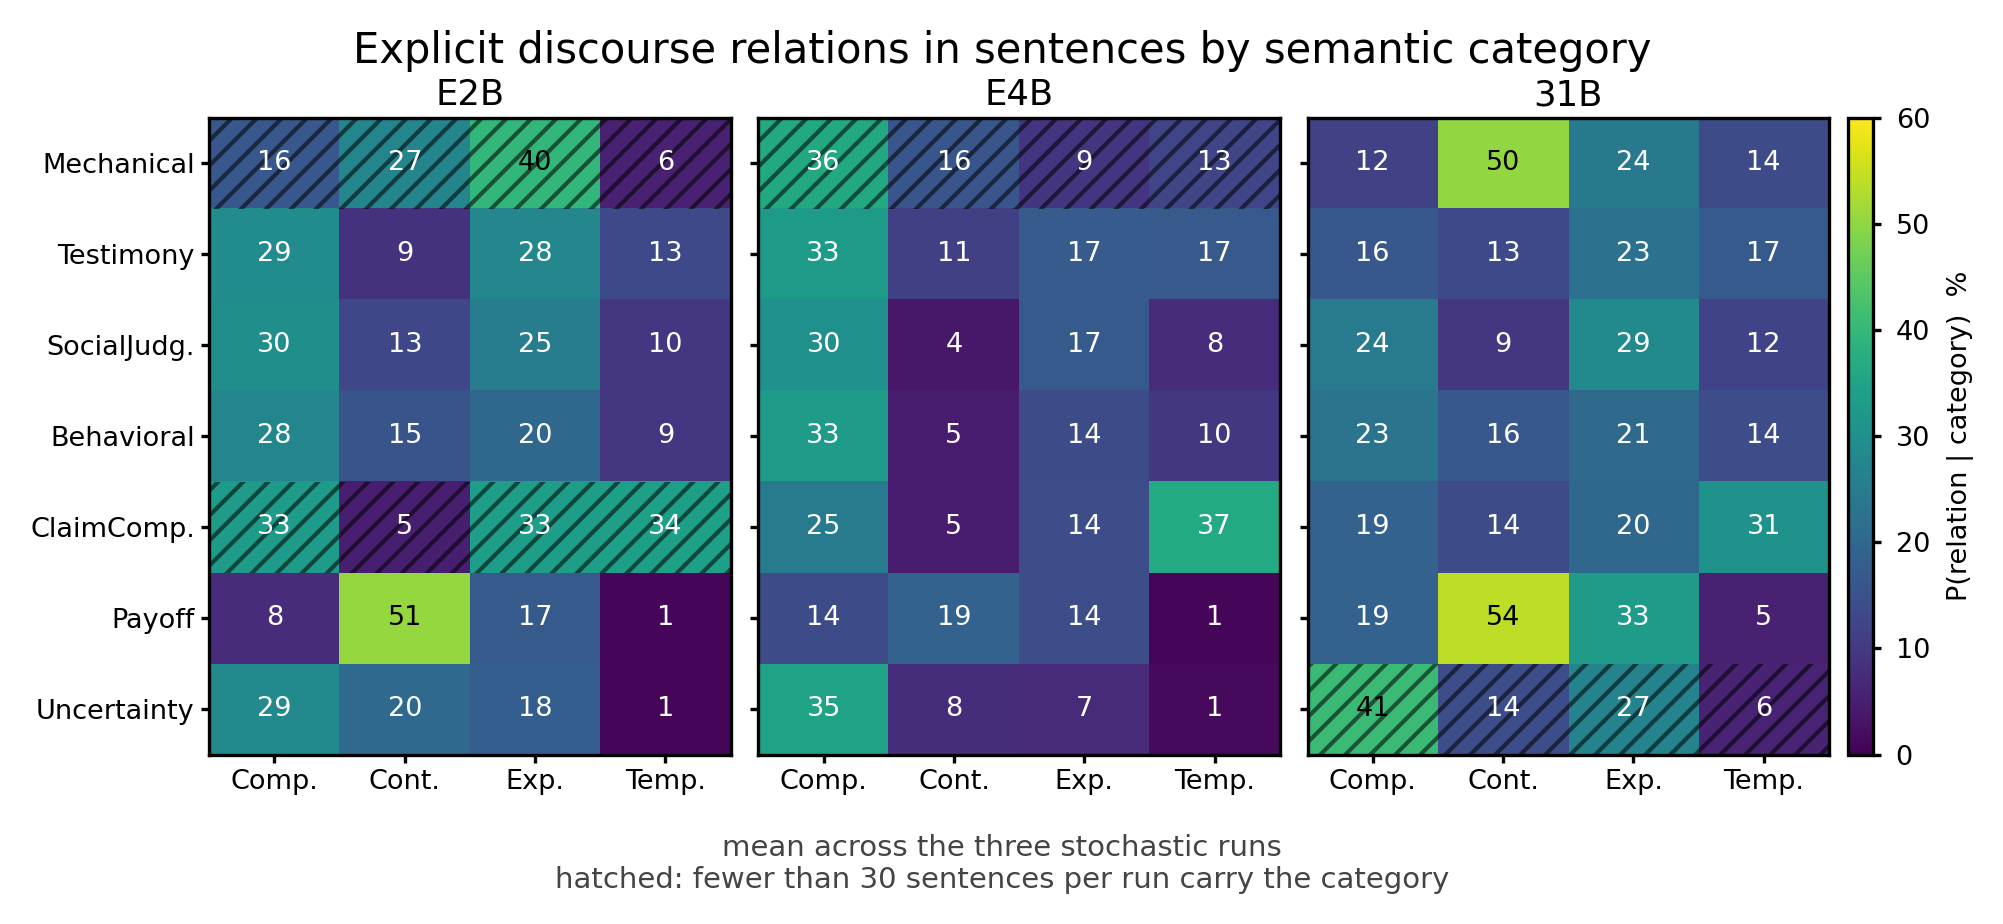

F2_joint_lift.png


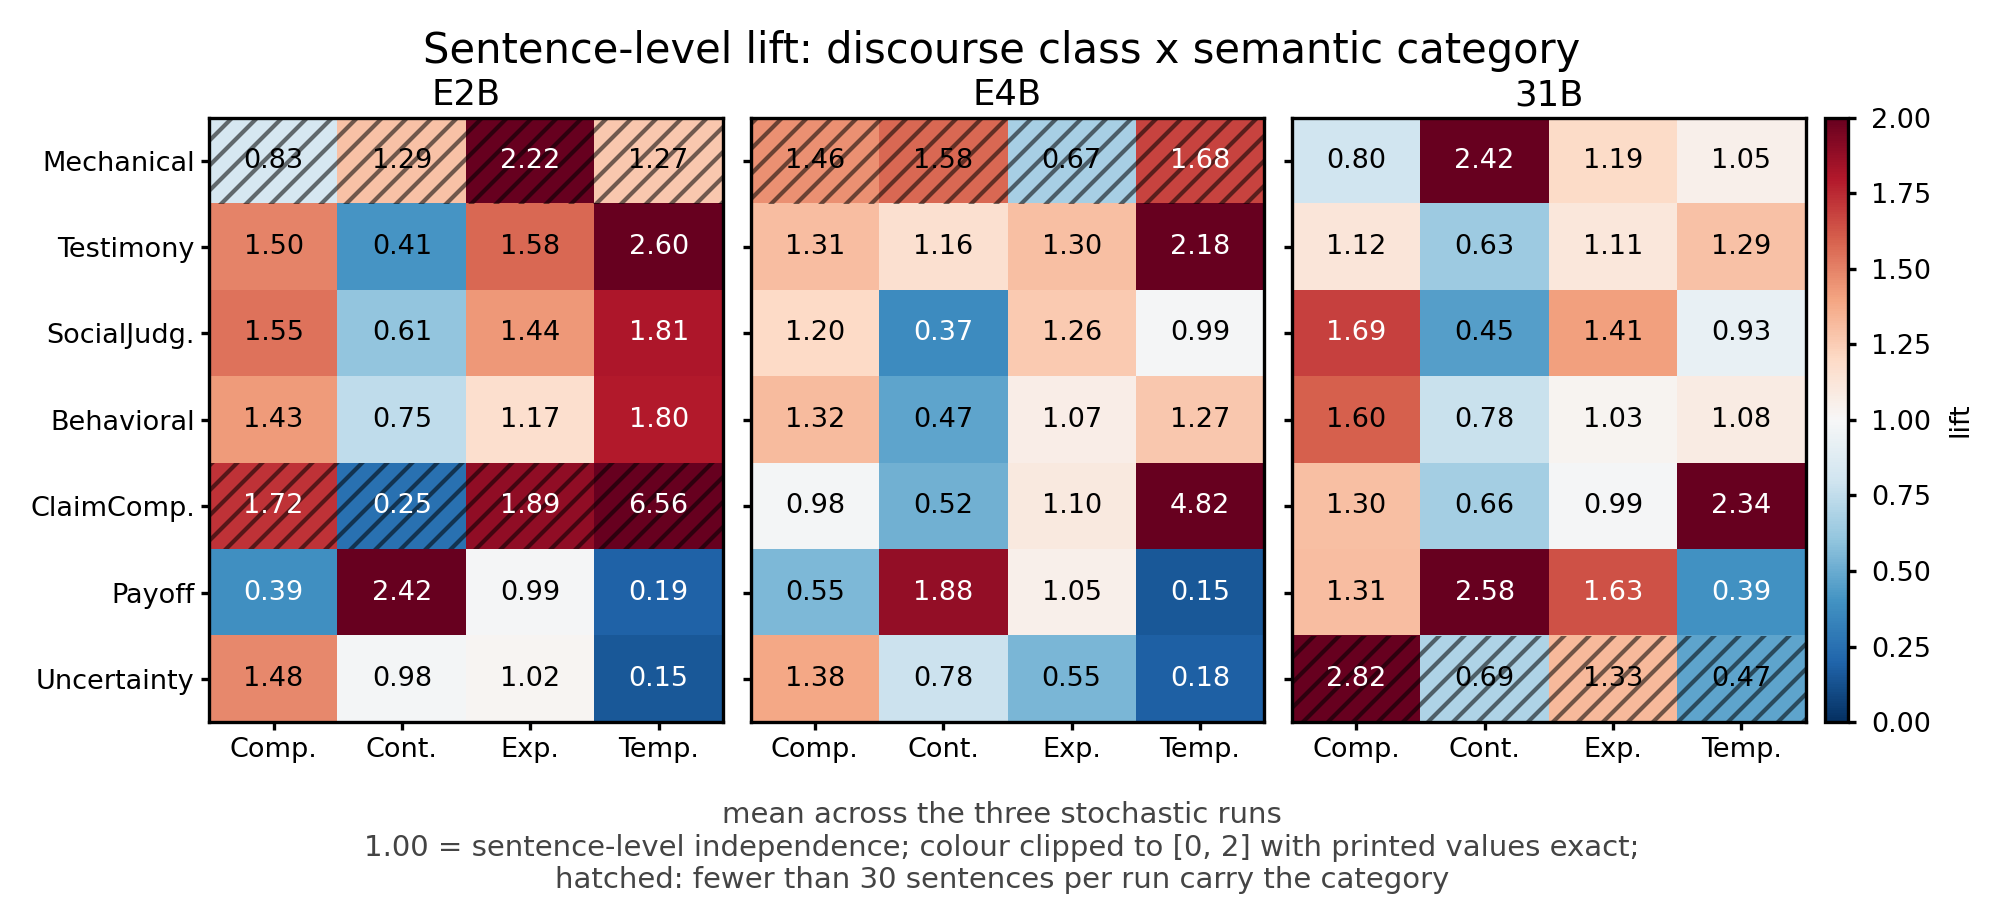

F1b_joint_conditional_prevalence_greedy.png


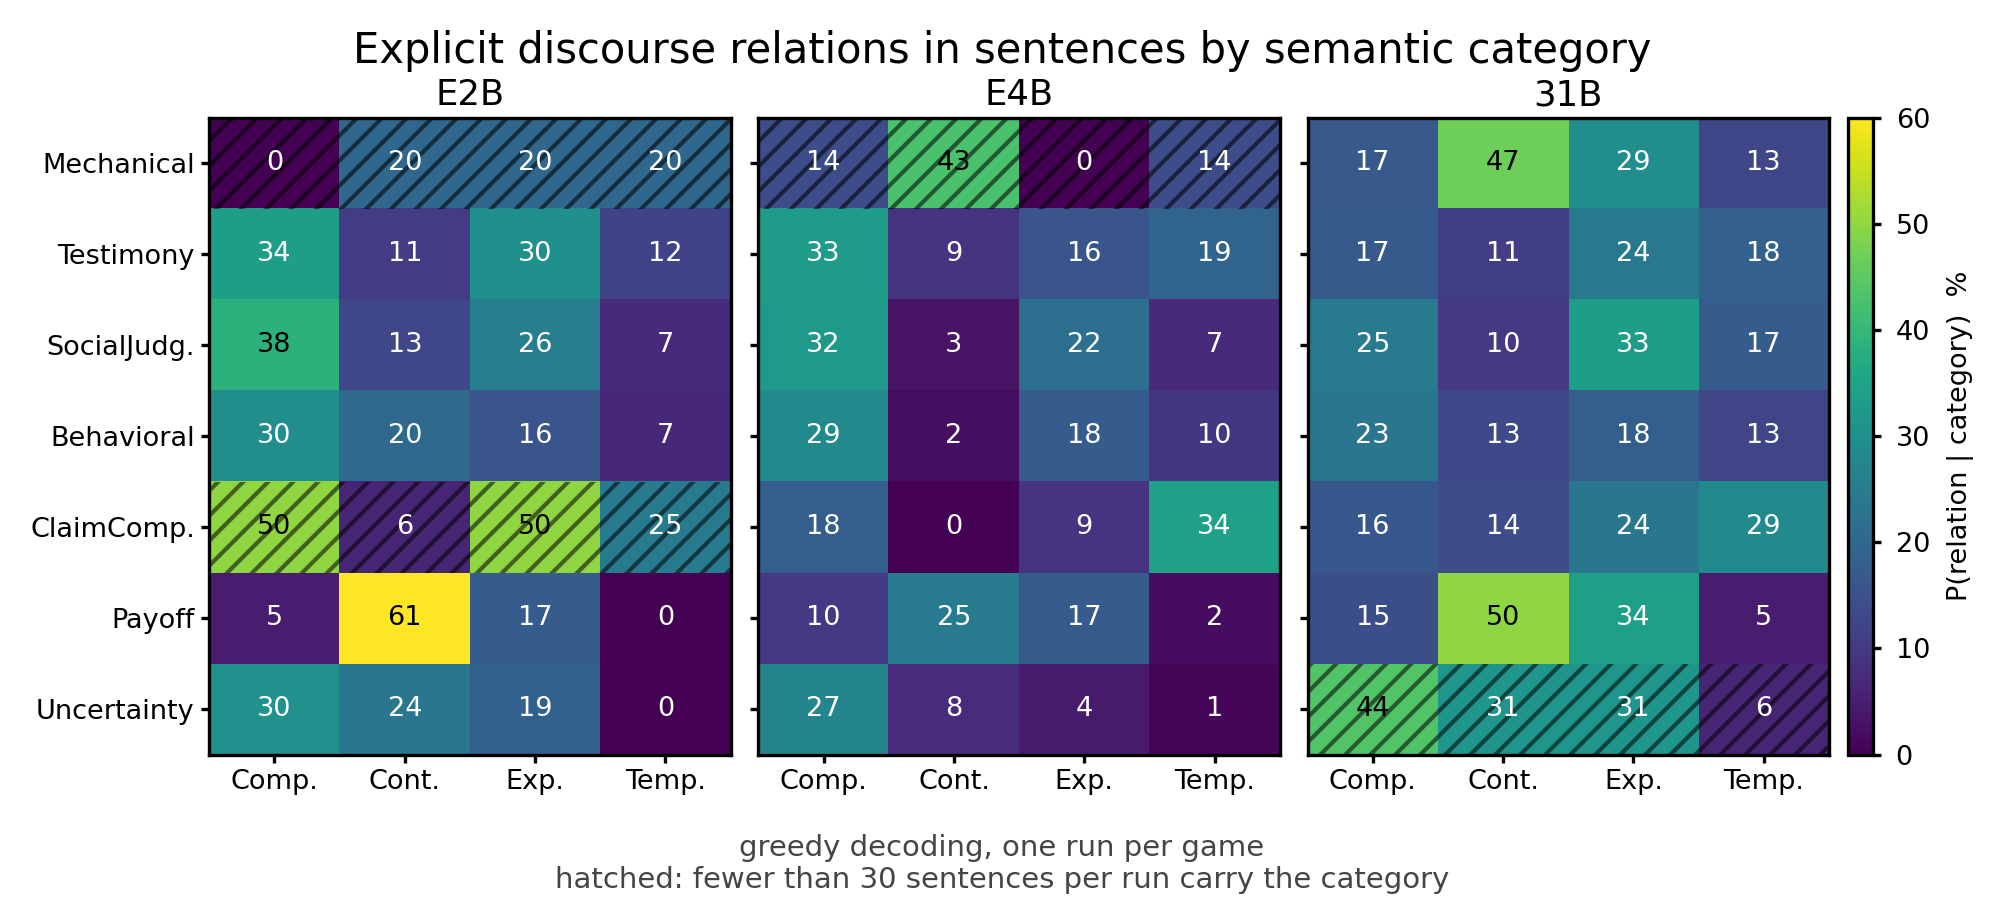

F2b_joint_lift_greedy.png


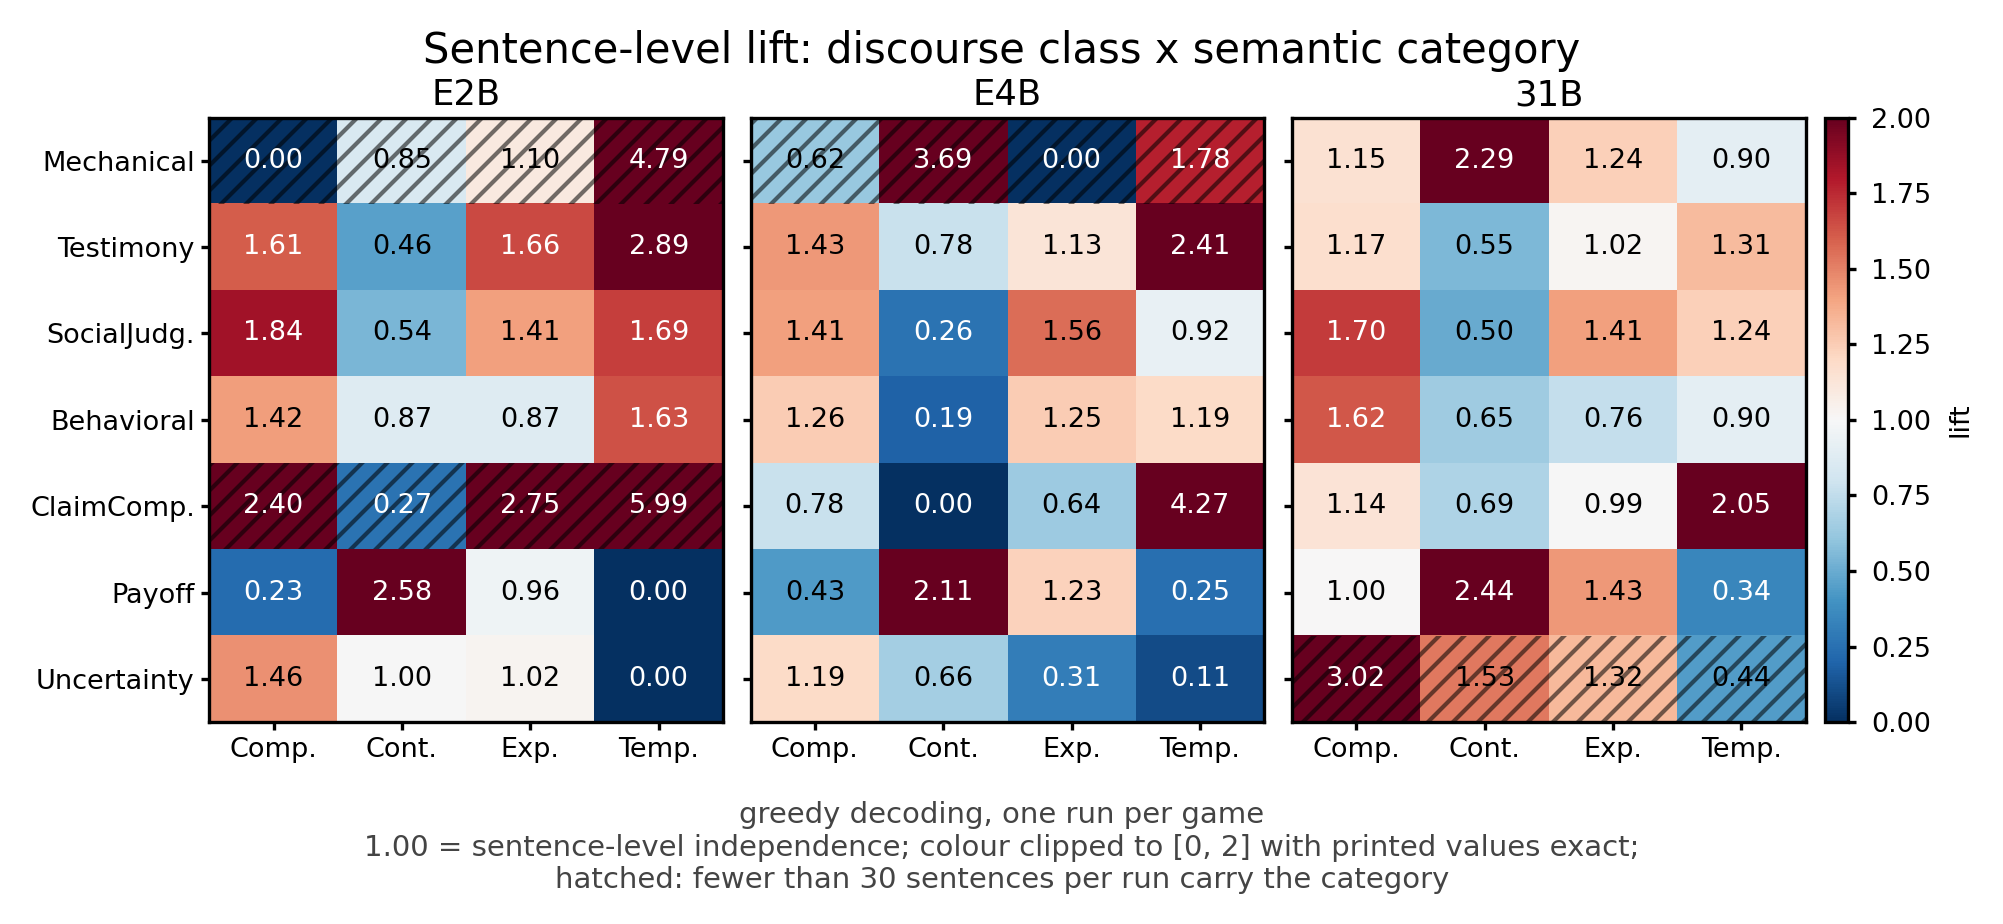

In [19]:
for path in figure_paths:
    print(path.name)
    display(Image(filename=str(path)))

### 12.2 Final checks

In [20]:
J1 = tables["J1_conditional_prevalence_run_level"]
J2 = tables["J2_conditional_prevalence_summary"]
J5 = tables["J5_bootstrap_model_differences"]

checks = [
    ("all 2,292 justifications represented",
     joint["justification_id"].nunique() == 2292),
    ("canonical corpus is 8,044 sentences", len(joint) == 8044),
    ("all 191 games present", joint["game_id"].nunique() == 191),
    ("all 5,504 accepted relations aligned",
     len(alignment["aligned"]) == 5504),
    ("nothing unaligned", len(alignment["unaligned"]) == 0),
    ("no validation check failed",
     not (tables["J0_validation_report"]["status"] == "FAIL").any()),
    ("top-level totals reproduce the frozen discourse analysis",
     alignment["aligned"]["top_level"].value_counts().to_dict()
     == {"Comparison": 1608, "Contingency": 1534,
         "Expansion": 1513, "Temporal": 849}),
    ("only the four PDTB top-level classes appear",
     set(J1["discourse_relation"].astype(str))
     == set(jf.TOP_LEVEL_ORDER) | {jf.ANY_RELATION}),
    ("Other is excluded from the comparative analysis",
     jf.OTHER_CATEGORY not in set(J1["semantic_category"].astype(str))),
    ("N(c,r) never exceeds N(c)",
     bool((J1["n_joint_sentences"] <= J1["n_semantic_sentences"]).all())),
    ("P(r|c) lies in [0, 1]",
     bool(J1["conditional_prevalence"].dropna().between(0, 1).all())),
    ("stochastic rows average 3 runs, greedy 1",
     set(J2.groupby("decoding_group", observed=True)["n_runs"]
         .unique().apply(tuple).to_dict().values()) == {(3,), (1,)}),
    ("greedy SD is undefined, never zero",
     J2.loc[J2["decoding_group"].astype(str).eq("Greedy"),
            "sd_conditional_prevalence"].isna().all()),
    ("stochastic and greedy never pooled",
     all(set(t["decoding_group"].astype(str)) <= {"Stochastic", "Greedy"}
         for t in tables.values() if "decoding_group" in t.columns)),
    ("bootstrap CI brackets its point estimate",
     bool(((J5["ci_low"] <= J5["difference"])
           & (J5["difference"] <= J5["ci_high"])).all())),
    ("bootstrap difference equals prevalence_a - prevalence_b",
     np.allclose(J5["difference"],
                 J5["prevalence_a"] - J5["prevalence_b"], equal_nan=True)),
    ("bootstrap is deterministic under the fixed seed",
     jf.conditional_prevalence_bootstrap(joint, "top_level")["ci_low"]
     .equals(J5["ci_low"])),
    ("every bootstrap replicate count is positive",
     bool((J5["n_valid_replicates"] > 0).all())),
]

for label, ok in checks:
    print(f"  [{'OK  ' if ok else 'FAIL'}] {label}")
assert all(ok for _, ok in checks), "a final check failed"
print()
print("All final checks passed.")

  [OK  ] all 2,292 justifications represented
  [OK  ] canonical corpus is 8,044 sentences
  [OK  ] all 191 games present
  [OK  ] all 5,504 accepted relations aligned
  [OK  ] nothing unaligned
  [OK  ] no validation check failed
  [OK  ] top-level totals reproduce the frozen discourse analysis
  [OK  ] only the four PDTB top-level classes appear
  [OK  ] Other is excluded from the comparative analysis
  [OK  ] N(c,r) never exceeds N(c)
  [OK  ] P(r|c) lies in [0, 1]
  [OK  ] stochastic rows average 3 runs, greedy 1
  [OK  ] greedy SD is undefined, never zero
  [OK  ] stochastic and greedy never pooled
  [OK  ] bootstrap CI brackets its point estimate
  [OK  ] bootstrap difference equals prevalence_a - prevalence_b
  [OK  ] bootstrap is deterministic under the fixed seed
  [OK  ] every bootstrap replicate count is positive

All final checks passed.


In [21]:
print(f"tables  -> {FINAL_TABLES.relative_to(REPO_ROOT)}")
for path in sorted(FINAL_TABLES.glob('*.csv')):
    print("   ", path.name)
print(f"figures -> {FINAL_FIGURES.relative_to(REPO_ROOT)}")
for path in sorted(FINAL_FIGURES.glob('*.png')):
    print("   ", path.name)

tables  -> analysis\cross_model\base\voting\prompt_v4\justification_analysis\joint_discourse_semantic\thesis_tables\final_joint
    J0_validation_report.csv
    J0b_unaligned_relations.csv
    J1_conditional_prevalence_run_level.csv
    J2_conditional_prevalence_summary.csv
    J3_joint_prevalence_lift_run_level.csv
    J3b_joint_prevalence_lift_summary.csv
    J4_any_relation_given_category.csv
    J5_bootstrap_model_differences.csv
    J6_finegrained_conditional_prevalence_run_level.csv
    J6b_finegrained_conditional_prevalence_summary.csv
    J7_finegrained_joint_prevalence_lift_summary.csv
figures -> analysis\cross_model\base\voting\prompt_v4\justification_analysis\joint_discourse_semantic\figures\final_joint
    F1_joint_conditional_prevalence.png
    F1b_joint_conditional_prevalence_greedy.png
    F2_joint_lift.png
    F2b_joint_lift_greedy.png
